In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
customer = pd.read_csv("../data/olist_customers_dataset.csv")
geolocation = pd.read_csv("../data/olist_geolocation_dataset.csv")
item = pd.read_csv("../data/olist_order_items_dataset.csv")
payment = pd.read_csv("../data/olist_order_payments_dataset.csv")
review = pd.read_csv("../data/olist_order_reviews_dataset.csv")
order = pd.read_csv("../data/olist_orders_dataset.csv")
product = pd.read_csv("../data/olist_products_dataset.csv")
seller = pd.read_csv("../data/olist_sellers_dataset.csv")
category = pd.read_csv("../data/product_category_name_translation.csv")

In [5]:
datasets = {"customer":customer,
            "order":order,
            "product":product,
            "category":category,
            "item":item,
            "payment":payment,
            "review":review,
            "seller":seller,
            "geolocation":geolocation
            }
for name,df in datasets.items():
    print(f"{name}: {df.shape}")

customer: (99441, 5)
order: (99441, 8)
product: (32951, 9)
category: (71, 2)
item: (112650, 7)
payment: (103886, 5)
review: (99224, 7)
seller: (3095, 4)
geolocation: (1000163, 5)


In [6]:
for name,df in datasets.items():
    print(f"\n{"="*50}")
    print(f"{name.upper()}")
    print(f"{"="*50}")
    print(df.columns.tolist())


CUSTOMER
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

ORDER
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

PRODUCT
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

CATEGORY
['product_category_name', 'product_category_name_english']

ITEM
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

PAYMENT
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEW
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

SELLER
['seller_id', 'seller_zip_code_prefix', 'sel

In [7]:
for name,df in datasets.items():
    print(f"\n{"="*50}")
    print(f"{name.upper()}")
    print(f"{"="*50}")
    print(df.head())


CUSTOMER
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

ORDER
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b1

In [8]:
for name,df in datasets.items():
    print(f"\n{"="*50}")
    print(f"{name.upper()}")
    print(f"{"="*50}")
    print(df.dtypes)


CUSTOMER
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

ORDER
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

PRODUCT
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

CATEGORY
product_category_name            str
product_category_name_english    str
dtype: object

ITEM
order_id            

In [9]:
#str to date conversion 
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in order_date_columns:
    order[col] = pd.to_datetime(order[col],errors="coerce")

In [10]:
order[order_date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [11]:
item["shipping_limit_date"] = pd.to_datetime(
    item["shipping_limit_date"],
    errors="coerce"
)

In [12]:
item["shipping_limit_date"].head()

0   2017-09-19 09:45:35
1   2017-05-03 11:05:13
2   2018-01-18 14:48:30
3   2018-08-15 10:10:18
4   2017-02-13 13:57:51
Name: shipping_limit_date, dtype: datetime64[us]

In [13]:
review_date_colms = [
    "review_creation_date",
    "review_answer_timestamp"
]
for col in review_date_colms:
    review[col] = pd.to_datetime(
        review[col],
        errors="coerce"
    )

In [14]:
print(f"answer {review["review_answer_timestamp"].dtype}")
print(f"creation {review["review_creation_date"].dtype}")

answer datetime64[us]
creation datetime64[us]


In [15]:
#Data Quality Profiling
#missing values summary function 
def missing_summary(df,name):
    summary = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent":(df.isna().mean() * 100).round(2)
    })
    summary = summary[summary["missing_count"]>0]
    summary = summary.sort_values(
        "missing_percent",
        ascending=False
    )
    print(f"\n{name.upper}")
    display(summary)

In [16]:
for name,df in datasets.items():
    print(name)
    missing_summary(df,name)

customer

<built-in method upper of str object at 0x7ff909cf05f0>


,missing_count,missing_percent


order

<built-in method upper of str object at 0x7ff9271d48b0>


,missing_count,missing_percent
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


product

<built-in method upper of str object at 0x7ff92632cd50>


...

,missing_count,missing_percent
review_comment_title,87656,88.34
review_comment_message,58247,58.70


seller

<built-in method upper of str object at 0x7ff8e7620ed0>


,missing_count,missing_percent


geolocation

<built-in method upper of str object at 0x7ff909c2e370>


,missing_count,missing_percent


In [17]:
#Data Quality Summary
quality_summary = []
for name,df in datasets.items():
    quality_summary.append({
        "table":name,
        "rows":len(df),
        "columns":len(df.columns),
        "duplicate_rows":df.duplicated().sum(),
        "missing_cells":df.isna().sum().sum(),
        "missing_percent":round(
            df.isna().sum().sum() / df.size * 100,
            2
        )
    })
quality_summary = pd.DataFrame(quality_summary)
quality_summary

,table,rows,columns,duplicate_rows,missing_cells,missing_percent
0,customer,99441,5,0,0,0.00
1,order,99441,8,0,4908,0.62
2,product,32951,9,0,2448,0.83
3,category,71,2,0,0,0.00
4,item,112650,7,0,0,0.00
5,payment,103886,5,0,0,0.00
6,review,99224,7,0,145903,21.01
7,seller,3095,4,0,0,0.00
8,geolocation,1000163,5,261831,0,0.00


## Table Grain

- customer: one row represents a customer-order relationship
- order: one row represents an order
- item: one row represents an item within an order
- payment: one row represents a payment record associated with an order
- review: one row represents a review record
- product: one row represents a product
- seller: one row represents a seller
- geolocation: one row represents a geolocation record for a ZIP-code prefix
- category: one row represents a product-category translation


In [18]:
#checking geolocation duplicates
print("Total rows: ",len(geolocation))
print("Unique ZIP prefixes: ",geolocation["geolocation_zip_code_prefix"].nunique())
print("Exact duplicate rows: ",
      geolocation.duplicated().sum())
print("Duplicate ZIP prefixes: ",
      geolocation["geolocation_zip_code_prefix"].duplicated().sum())

Total rows:  1000163
Unique ZIP prefixes:  19015
Exact duplicate rows:  261831
Duplicate ZIP prefixes:  981148


In [19]:
geo_duplicate = geolocation[
    geolocation.duplicated(keep=False)
].sort_values(
    by=geolocation.columns.tolist()
)
geo_duplicate.head(20)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
519,1001,-23.551337,-46.634027,sao paulo,SP
583,1001,-23.551337,-46.634027,sao paulo,SP
818,1001,-23.551337,-46.634027,sao paulo,SP
206,1001,-23.550498,-46.634338,sao paulo,SP
429,1001,-23.550498,-46.634338,sao paulo,SP
596,1001,-23.550498,-46.634338,sao paulo,SP
639,1001,-23.550498,-46.634338,sao paulo,SP
771,1001,-23.550498,-46.634338,sao paulo,SP
912,1001,-23.550498,-46.634338,sao paulo,SP
985,1001,-23.550498,-46.634338,sao paulo,SP


In [20]:
geo_clean_test = geolocation.drop_duplicates()
print("original rows: ",len(geolocation))
print("After exact duplicate removal: ",len(geo_clean_test))
print("Rows removed: ",len(geolocation)-len(geo_clean_test))

original rows:  1000163
After exact duplicate removal:  738332
Rows removed:  261831


### Geolocation Data Quality Findings

The geolocation dataset contains 1,000,163 rows and 19,015
unique ZIP-code prefixes.

There are 261,831 exact duplicate rows. These duplicates
will be investigated and removed from the cleaned version
of the dataset.

ZIP-code prefixes are highly repetitive, with 981,148 rows
containing a ZIP prefix that appears elsewhere. This is not
treated as a duplicate issue because a ZIP-code prefix may
have multiple geographic observations.

The geolocation table therefore requires careful handling
during joins to avoid row multiplication.


In [21]:
#removing duplicates row from geolocation
geo_clean = geolocation.drop_duplicates().copy()
geo_clean.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [22]:
#checking primary keys
print("Customer rows:", len(customer))
print("Unique customer_id:", customer["customer_id"].nunique())

print("order Rows:", len(order))
print("Unique order_id:", order["order_id"].nunique())

print("Product rows:", len(product))
print("Unique product_id:", product["product_id"].nunique())

print("Seller rows:", len(seller))
print("Unique seller_id:", seller["seller_id"].nunique())


Customer rows: 99441
Unique customer_id: 99441
order Rows: 99441
Unique order_id: 99441
Product rows: 32951
Unique product_id: 32951
Seller rows: 3095
Unique seller_id: 3095


In [23]:
print("customer_id:",
      customer["customer_id"].nunique())

print("customer_unique_id:",
      customer["customer_unique_id"].nunique())
print("Repeated customer:",
      customer["customer_id"].nunique()-customer["customer_unique_id"].nunique())


customer_id: 99441
customer_unique_id: 96096
Repeated customer: 3345


In [24]:
customer.groupby(
    "customer_unique_id"
)["customer_id"].nunique().value_counts()

customer_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [25]:
missing_orders = item[
    ~item["order_id"].isin(order["order_id"])
]

print("Item rows with invalid order_id:", len(missing_orders))
missing_products = item[
    ~item["product_id"].isin(product["product_id"])
]

print("Item rows with invalid product_id:", len(missing_products))
missing_sellers = item[
    ~item["seller_id"].isin(seller["seller_id"])
]

print("Item rows with invalid seller_id:", len(missing_sellers))
missing_customers = order[
    ~order["customer_id"].isin(customer["customer_id"])
]

print("Orders with invalid customer_id:", len(missing_customers))


Item rows with invalid order_id: 0
Item rows with invalid product_id: 0
Item rows with invalid seller_id: 0
Orders with invalid customer_id: 0


In [26]:
missing_report = []

for table_name, df in datasets.items():
    
    for column in df.columns:
        
        missing_count = df[column].isna().sum()
        total_count = len(df)
        
        missing_report.append({
            "table": table_name,
            "column": column,
            "total_rows": total_count,
            "missing_count": missing_count,
            "missing_percentage": round(
                (missing_count / total_count) * 100, 2
            ),
            "data_type": str(df[column].dtype)
        })

missing_report = pd.DataFrame(missing_report)

missing_report = missing_report[
    missing_report["missing_count"] > 0
].sort_values(
    by="missing_percentage",
    ascending=False
)

missing_report


,table,column,total_rows,missing_count,missing_percentage,data_type
39,review,review_comment_title,99224,87656,88.34,str
40,review,review_comment_message,99224,58247,58.70,str
11,order,order_delivered_customer_date,99441,2965,2.98,datetime64[us]
15,product,product_name_lenght,32951,610,1.85,float64
14,product,product_category_name,32951,610,1.85,str
16,product,product_description_lenght,32951,610,1.85,float64
17,product,product_photos_qty,32951,610,1.85,float64
10,order,order_delivered_carrier_date,99441,1783,1.79,datetime64[us]
9,order,order_approved_at,99441,160,0.16,datetime64[us]
19,product,product_length_cm,32951,2,0.01,float64


In [27]:
order[
    order["order_delivered_customer_date"].isna()
][[
    "order_id",
    "order_status",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]].head(20)


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT
44,ee64d42b8cf066f35eac1cf57de1aa85,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT
103,0760a852e4e9d89eb77bf631eaaf1c84,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT
128,15bed8e2fec7fdbadb186b57c46c92f2,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT
154,6942b8da583c2f9957e990d028607019,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT
162,36530871a5e80138db53bcfd8a104d90,shipped,2017-05-09 11:48:37,2017-05-11 11:45:14,2017-05-11 13:21:47,NaT
231,4d630f57194f5aba1a3d12ce23e71cd9,shipped,2017-11-17 19:53:21,2017-11-18 19:50:31,2017-11-22 17:28:34,NaT
266,8e24261a7e58791d10cb1bf9da94df5c,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT
299,3b4ad687e7e5190db827e1ae5a8989dd,shipped,2018-06-28 12:52:15,2018-06-28 13:11:09,2018-07-04 15:20:00,NaT
305,b68d69564a79dea4776afa33d1d2fcab,shipped,2018-02-28 08:57:03,2018-02-28 10:40:35,2018-03-05 16:10:13,NaT


In [28]:
order[
    order["order_delivered_customer_date"].isna()
]["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Visualisation

In [29]:
for name,df in datasets.items():
    print(f"\n{"="*50}")
    print(f"{name.upper()}")
    print(f"{"="*50}")
    print(df.columns.tolist())


CUSTOMER
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

ORDER
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

PRODUCT
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

CATEGORY
['product_category_name', 'product_category_name_english']

ITEM
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

PAYMENT
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEW
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

SELLER
['seller_id', 'seller_zip_code_prefix', 'sel

In [30]:
#creating sales data
sales = pd.merge(
    order[["order_id","order_purchase_timestamp"]],
    item[["order_id","price","freight_value"]],
    on="order_id",
    how="inner"
)

In [31]:
sales["year"]=sales["order_purchase_timestamp"].dt.year
sales["total_price"] = sales["price"]+sales["freight_value"]
sales.head()

,order_id,order_purchase_timestamp,price,freight_value,year,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,8.72,2017,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70,22.76,2018,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90,19.22,2018,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,27.20,2017,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,8.72,2018,28.62


In [32]:
yearly_sales = (
    sales.groupby("year")["total_price"]
    .sum().reset_index()
)

yearly_sales

,year,total_price
0,2016,57183.21
1,2017,7142672.43
2,2018,8643697.60


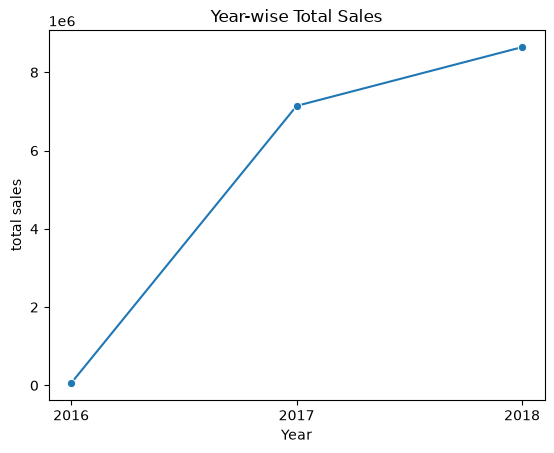

In [33]:
sns.lineplot(
    x=yearly_sales["year"].astype(str),
    y=yearly_sales["total_price"],
    marker="o"
)
plt.title("Year-wise Total Sales")
plt.xlabel("Year")
plt.ylabel("total sales")
plt.xticks(rotation=0)
plt.show()

In [34]:
product_wise_sale = pd.merge(
    item[["product_id","price"]],
    product[["product_id","product_category_name"]],
    on="product_id"
)
product_wise_sale = pd.merge(
    product_wise_sale,
    category[[
        "product_category_name",
        "product_category_name_english"
    ]],
    on="product_category_name",
    how="left"
)
product_wise_sale.head()

,product_id,price,product_category_name,product_category_name_english
0,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff,cool_stuff
1,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop,pet_shop
2,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao,furniture_decor
3,7634da152a4610f1595efa32f14722fc,12.99,perfumaria,perfumery
4,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim,garden_tools


In [35]:
category_sales = (
    product_wise_sale
    .groupby("product_category_name_english")["price"]
    .sum().sort_values(ascending=False)
)
category_sales.head()

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
Name: price, dtype: float64

Top 10 category wise sales

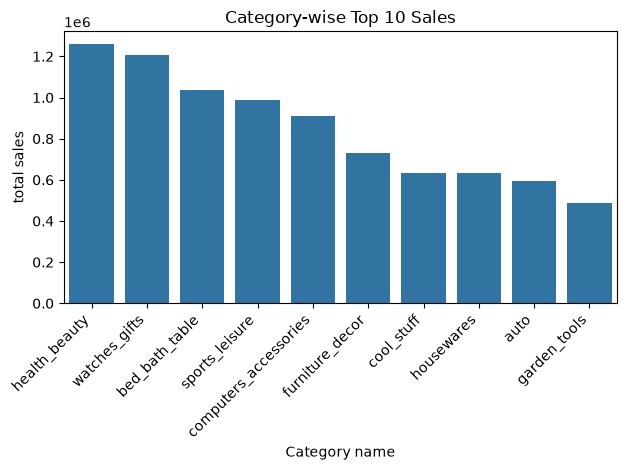

In [36]:
category_sales_top_10 = category_sales.head(10)
sns.barplot(
    x=category_sales_top_10.index,
    y=category_sales_top_10.values
)
plt.title("Category-wise Top 10 Sales")
plt.xlabel("Category name")
plt.ylabel("total sales")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()


Top 10 Seller wise sales

In [37]:
seller_sales = pd.merge(
    item[["seller_id","price"]],
    seller[["seller_id"]],
    on="seller_id",
    how="inner"
)
seller_totalsales = (
    seller_sales.groupby("seller_id")["price"].sum()
    .sort_values(ascending=False)
)
seller_totalsales.head()

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
Name: price, dtype: float64

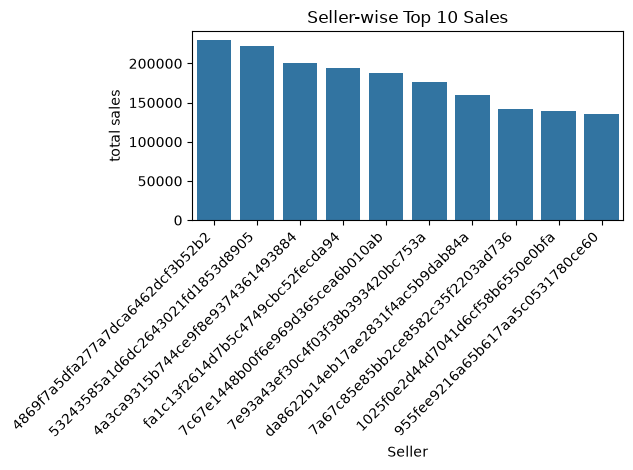

In [38]:
seller_top10 = seller_totalsales.head(10)
sns.barplot(
    x=seller_top10.index,
    y=seller_top10.values
)
plt.title("Seller-wise Top 10 Sales")
plt.xlabel("Seller")
plt.ylabel("total sales")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

Plotly Express graphs

In [39]:
import plotly.express as px
fig=px.bar(x=seller_top10.index,
           y=seller_top10.values,
           labels={
               "x":"Seller",
               "y": "Sales"
           },
           title="Top 10 Sellers")
fig.show()

In [40]:
payment_type=payment["payment_type"].value_counts()
payment_graph = px.pie(
    names=payment_type.index,
    values=payment_type.values,
    title="Payment Type"
)
payment_graph.update_layout(
    title_x=0.5
)
payment_graph.show()

In [41]:
customer_state = (
    customer
    .groupby("customer_state")
    .size()
    .reset_index(name="customers")
)

geo_small = (
    geo_clean
    .groupby("geolocation_state")
    [["geolocation_lat", "geolocation_lng",]]
    .mean()
    .reset_index()
)


In [42]:
customer_state = customer_state.merge(
    geo_small,
    left_on=["customer_state"],
    right_on=["geolocation_state"],
    how="left"
)
customer_state


,customer_state,customers,geolocation_state,geolocation_lat,geolocation_lng
0,AC,81,AC,-9.709319,-68.453261
1,AL,413,AL,-9.592373,-36.067588
2,AM,148,AM,-3.346562,-60.535697
3,AP,68,AP,0.073767,-51.204454
4,BA,3380,BA,-13.062407,-39.627164
5,CE,1336,CE,-4.395199,-39.028335
6,DF,2140,DF,-15.814327,-47.979684
7,ES,2033,ES,-20.078083,-40.516053
8,GO,2020,GO,-16.567440,-49.344447
9,MA,747,MA,-3.821203,-44.818273


In [43]:
custo_map = px.scatter_map(
    customer_state,
    lat="geolocation_lat",
    lon="geolocation_lng",
    size="customers",
    color="customers",
    hover_name="customer_state",
    zoom=3,
    height=700,
    title="Customers by state"
)

custo_map.show()
